V2: Optimize v1, improve lag accuracy, and add tomato lag.

1. Data Structures

In [11]:
import pandas as pd

# Load the grocery avocado_price file
df1 = pd.read_csv("avocado_price.csv")
print("1.Grocery avocado_price")
print(df1.head())

# Load avocado_imported_from_mexico file
df2 = pd.read_csv("avocado_imported_from_mexico.csv")
print("2.avocado_imported_from_mexico")
print(df2.head())

# Load cpi_20160101_cleaned file
df3 = pd.read_csv("cpi_20160101_cleaned.csv")
print("3.cpi_20160101_cleaned")
print(df3.head())

# Load clean-fx_rate file
df4 = pd.read_csv("clean-fx_rate.csv")
print("4.clean-fx_rate")
print(df4.head())

# Load mexico_weather_cleanedup file
df5 = pd.read_csv("mexico_weather_cleanedup.csv")
print("5.mexico_weather_cleanedup")
print(df5.head())

# Load Canada fuel price file
df6 = pd.read_csv("18100001.csv")
print("6.Canada fuel price")
print(df6.head())

# Load usgasprice_cleanedup file
df7 = pd.read_csv("usgasprice_cleanedup.csv")
print("7.usgasprice_cleanedup")
print(df7.head())

# Load mexico_fuel_prices_201601 file
df8 = pd.read_csv("mexico_fuel_prices_201601.csv")
print("8.mexico_fuel_prices_201601")
print(df8.head())

# Load the grocery tomato_price file
df9 = pd.read_csv("tomato_price.csv")
print("9.Grocery tomato_price")
print(df9.head())

# Load tomato_import_mexico_us file
df10 = pd.read_csv("tomato_import_mexico_us.csv")
print("10.tomato_import_mexico_us")
print(df10.head())

1.Grocery avocado_price
  REF_DATE                        GEO           DGUID       Products      UOM  \
0  2017-01                     Canada  2021A000011124  Avocado, unit  Dollars   
1  2017-01  Newfoundland and Labrador     2021A000210  Avocado, unit  Dollars   
2  2017-01       Prince Edward Island     2021A000211  Avocado, unit  Dollars   
3  2017-01                Nova Scotia     2021A000212  Avocado, unit  Dollars   
4  2017-01              New Brunswick     2021A000213  Avocado, unit  Dollars   

   UOM_ID SCALAR_FACTOR  SCALAR_ID       VECTOR  COORDINATE  VALUE  STATUS  \
0      81         units          0  v1353834299       11.29   1.51     NaN   
1      81         units          0  v1159447003        1.29   2.06     NaN   
2      81         units          0  v1159447043        2.29   1.40     NaN   
3      81         units          0  v1159447083        3.29   1.35     NaN   
4      81         units          0  v1159447123        4.29   1.42     NaN   

   SYMBOL  TERMINATE

2. Calculate Real Prices

2.1 Divide Avocado prices by the Canadian CPI. This removes the general "inflation noise."

In [12]:
import pandas as pd

# Load dataset
df_avocado_price = pd.read_csv("avocado_price.csv")
df_cpi = pd.read_csv("cpi_20160101_cleaned.csv")

# 1. Transform CPI from Wide to Long
food_cpi = df_cpi[df_cpi['Product'] == 'Food'].melt(
    id_vars=['Product'],
    var_name='raw_date',
    value_name='cpi_value'
)

# 2. Format the date to 'YYYY-MM' (e.g., '201601' -> '2016-01')
food_cpi['date'] = pd.to_datetime(food_cpi['raw_date'], format='%Y%m').dt.strftime('%Y-%m')
food_cpi = food_cpi[['date', 'cpi_value']]

# 3. Clean the Avocado Data
avocado_canada = df_avocado_price[df_avocado_price['GEO'] == 'Canada'].copy()
avocado_canada['date'] = pd.to_datetime(avocado_canada['REF_DATE']).dt.strftime('%Y-%m')

# 4. Merge with CPI long-format data
avocado_price_merged = pd.merge(avocado_canada, food_cpi, on='date', how='left')

# 5. Deflate the Price
avocado_price_merged['real_price'] = (avocado_price_merged['VALUE'] / avocado_price_merged['cpi_value']) * 100

print(avocado_price_merged.head())

  REF_DATE     GEO           DGUID       Products      UOM  UOM_ID  \
0  2017-01  Canada  2021A000011124  Avocado, unit  Dollars      81   
1  2017-02  Canada  2021A000011124  Avocado, unit  Dollars      81   
2  2017-03  Canada  2021A000011124  Avocado, unit  Dollars      81   
3  2017-04  Canada  2021A000011124  Avocado, unit  Dollars      81   
4  2017-05  Canada  2021A000011124  Avocado, unit  Dollars      81   

  SCALAR_FACTOR  SCALAR_ID       VECTOR  COORDINATE  VALUE  STATUS  SYMBOL  \
0         units          0  v1353834299       11.29   1.51     NaN     NaN   
1         units          0  v1353834299       11.29   1.52     NaN     NaN   
2         units          0  v1353834299       11.29   1.66     NaN     NaN   
3         units          0  v1353834299       11.29   1.92     NaN     NaN   
4         units          0  v1353834299       11.29   2.14     NaN     NaN   

   TERMINATED  DECIMALS     date  cpi_value  real_price  
0         NaN         2  2017-01      141.5    1.067

2.2 Divide tomato prices by the Canadian CPI. This removes the general "inflation noise."

In [13]:
import pandas as pd

# Load dataset
df_tomato_price = pd.read_csv("tomato_price.csv")
df_cpi = pd.read_csv("cpi_20160101_cleaned.csv")

# 1. Transform CPI from Wide to Long
food_cpi = df_cpi[df_cpi['Product'] == 'Food'].melt(
    id_vars=['Product'],
    var_name='raw_date',
    value_name='cpi_value'
)

# 2. Format the date to 'YYYY-MM' (e.g., '201601' -> '2016-01')
food_cpi['date'] = pd.to_datetime(food_cpi['raw_date'], format='%Y%m').dt.strftime('%Y-%m')
food_cpi = food_cpi[['date', 'cpi_value']]

# 3. Clean the tomato Data
tomato_canada = df_tomato_price[df_tomato_price['GEO'] == 'Canada'].copy()
tomato_canada['date'] = pd.to_datetime(tomato_canada['REF_DATE']).dt.strftime('%Y-%m')

# 4. Merge with CPI long-format data
tomato_price_merged = pd.merge(avocado_canada, food_cpi, on='date', how='left')

# 5. Deflate the Price
tomato_price_merged['real_price'] = (tomato_price_merged['VALUE'] / tomato_price_merged['cpi_value']) * 100

print(tomato_price_merged.head())

  REF_DATE     GEO           DGUID       Products      UOM  UOM_ID  \
0  2017-01  Canada  2021A000011124  Avocado, unit  Dollars      81   
1  2017-02  Canada  2021A000011124  Avocado, unit  Dollars      81   
2  2017-03  Canada  2021A000011124  Avocado, unit  Dollars      81   
3  2017-04  Canada  2021A000011124  Avocado, unit  Dollars      81   
4  2017-05  Canada  2021A000011124  Avocado, unit  Dollars      81   

  SCALAR_FACTOR  SCALAR_ID       VECTOR  COORDINATE  VALUE  STATUS  SYMBOL  \
0         units          0  v1353834299       11.29   1.51     NaN     NaN   
1         units          0  v1353834299       11.29   1.52     NaN     NaN   
2         units          0  v1353834299       11.29   1.66     NaN     NaN   
3         units          0  v1353834299       11.29   1.92     NaN     NaN   
4         units          0  v1353834299       11.29   2.14     NaN     NaN   

   TERMINATED  DECIMALS     date  cpi_value  real_price  
0         NaN         2  2017-01      141.5    1.067

2.3 Calculate the Weighted Fuel Signal
 The Formula:$$Total\ Fuel\ Signal = (0.7 \times U.S.\ Price) + (0.2 \times Mexico\ Price) + (0.1 \times Canada\ Price)$$

In [14]:
import pandas as pd
# Load dataset
df_ca_fuel_raw = pd.read_csv("18100001.csv")
df_us_fuel_raw = pd.read_csv("usgasprice_cleanedup.csv")
df_mx_fuel_raw = pd.read_csv("mexico_fuel_prices_201601.csv")
df_fx_rate_cleaned = pd.read_csv("clean-fx_rate.csv")


# 1. PREPARE EXCHANGE RATES
df_fx = df_fx_rate_cleaned.copy()
df_fx['date'] = pd.to_datetime(df_fx['date']).dt.strftime('%Y-%m')

# 2. CLEAN CANADA DATA
df_ca_fuel = df_ca_fuel_raw[df_ca_fuel_raw['Type of fuel'].str.contains("Regular unleaded gasoline")].copy()
df_ca_fuel.loc[:, 'date'] = pd.to_datetime(df_ca_fuel['REF_DATE']).dt.strftime('%Y-%m')
df_ca_fuel.loc[:, 'ca_price_cad_l'] = df_ca_fuel['VALUE'] / 100
# Group by 'date' to get the monthly average across all regions
# This reduces ~2070 rows down to ~110 rows (one per month)
df_ca_fuel = df_ca_fuel.groupby('date')['ca_price_cad_l'].mean().reset_index()
print(f"Canada Fuel Data synchronized: {len(df_ca_fuel)} months prepared.")

# 3. CLEAN USA DATA
# jan-2016 matches %b-%Y format
df_us_fuel = df_us_fuel_raw.copy()
df_us_fuel['date'] = pd.to_datetime(df_us_fuel['Date'], format='%b-%Y').dt.strftime('%Y-%m')
# take the mean of the price per gallon for each month
df_us_fuel = df_us_fuel.groupby('date')['U.S. No 2 Diesel Retail Prices (Dollars per Gallon)'].mean().reset_index()
# Merge FX into US fuel
df_us_fuel = df_us_fuel.merge(df_fx[['date', 'USD_CAD']], on='date', how='left')
# (Price/Gallon / 3.785) * USD_CAD rate
df_us_fuel['us_price_cad_l'] = (df_us_fuel['U.S. No 2 Diesel Retail Prices (Dollars per Gallon)'] / 3.785) * df_us_fuel['USD_CAD']

print(f"U.S. Fuel Data synchronized: {len(df_us_fuel)} months prepared.")

# 4. CLEAN MEXICO DATA
df_mx_fuel = df_mx_fuel_raw.copy()
df_mx_fuel['date'] = pd.to_datetime(df_mx_fuel['Date']).dt.strftime('%Y-%m')
# Merge FX into Mexico fuel
df_mx_fuel = df_mx_fuel.merge(df_fx[['date', 'MXN_CAD']], on='date', how='left')
# Diesel_MXN_L * MXN_CAD rate
df_mx_fuel['mx_price_cad_l'] = df_mx_fuel['Diesel_MXN_L'] * df_mx_fuel['MXN_CAD']

print(f"Mexico Fuel Data synchronized: {len(df_mx_fuel)} months prepared.")

# 5. Filter all dataframes to start at 2017-01
start_date = '2017-01'
df_fx = df_fx[df_fx['date'] >= start_date]
df_ca_fuel = df_ca_fuel[df_ca_fuel['date'] >= start_date]
df_us_fuel = df_us_fuel[df_us_fuel['date'] >= start_date]
df_mx_fuel = df_mx_fuel[df_mx_fuel['date'] >= start_date]

# 6. MERGE & CALCULATE SIGNAL
fuel_signal = df_ca_fuel[['date', 'ca_price_cad_l']].merge(df_us_fuel[['date', 'us_price_cad_l']], on='date')
fuel_signal = fuel_signal.merge(df_mx_fuel[['date', 'mx_price_cad_l']], on='date')

# Fuel Formula
fuel_signal['total_fuel_signal'] = (0.7 * fuel_signal['us_price_cad_l']) + \
                                   (0.2 * fuel_signal['mx_price_cad_l']) + \
                                   (0.1 * fuel_signal['ca_price_cad_l'])

print(fuel_signal.head())
print(f"Canada Fuel Data synchronized: {len(df_ca_fuel)} months prepared.")
print(f"U.S. Fuel Data synchronized: {len(df_us_fuel)} months prepared.")
print(f"Mexico Fuel Data synchronized: {len(df_mx_fuel)} months prepared.")
print(f"Mixed Fuel Data synchronized: {len(fuel_signal)} months prepared.")

Canada Fuel Data synchronized: 565 months prepared.
U.S. Fuel Data synchronized: 122 months prepared.
Mexico Fuel Data synchronized: 123 months prepared.
      date  ca_price_cad_l  us_price_cad_l  mx_price_cad_l  total_fuel_signal
0  2017-01        1.135895        0.899285        1.051133           0.953316
1  2017-02        1.077737        0.889268        1.114695           0.953200
2  2017-03        1.073263        0.903246        1.210685           0.981735
3  2017-04        1.156947        0.917187        1.263200           1.010366
4  2017-05        1.109632        0.920315        1.292853           1.013754
Canada Fuel Data synchronized: 109 months prepared.
U.S. Fuel Data synchronized: 110 months prepared.
Mexico Fuel Data synchronized: 111 months prepared.
Mixed Fuel Data synchronized: 109 months prepared.


3. Feature Engineering

3.1 Avocado grocery price Lag: using CCF or corrcoef

3.1.1 fuel- 1 month positive, 4 months negative

Master dataframe created with 108 aligned months.
Shape of X: (107,)
Shape of Y: (107,)


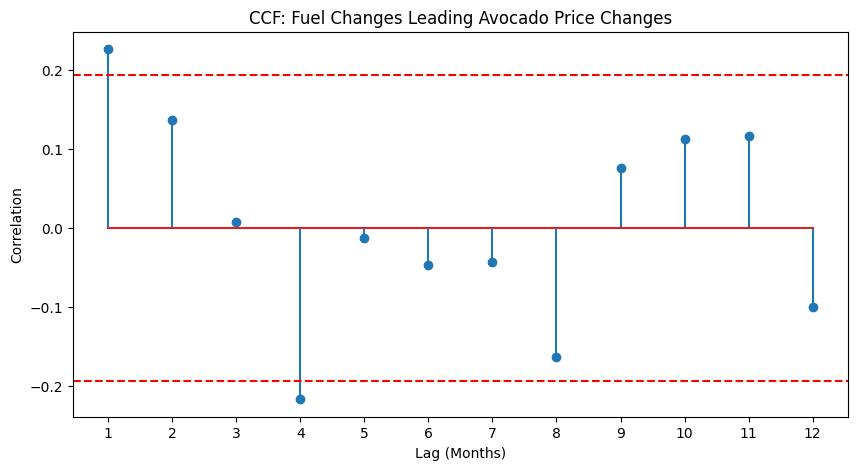

Strongest correlation at lag 1 months: 0.227


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Merge fuel and price data
df_ccf_price_fuel = pd.merge(
    fuel_signal[['date', 'total_fuel_signal']],
    avocado_price_merged[['date', 'real_price']],
    on='date',
    how='inner'
)
# Sort by time
df_ccf_price_fuel = df_ccf_price_fuel.sort_values('date').reset_index(drop=True)

print(f"Master dataframe created with {len(df_ccf_price_fuel)} aligned months.")

# 2. Log transform (economic data works better in logs)
df_log = np.log(df_ccf_price_fuel[['total_fuel_signal', 'real_price']])

# 3. Difference to remove trend
df_diff = df_log.diff().dropna()
x = df_diff['total_fuel_signal']   # Fuel
y = df_diff['real_price']          # Avocado price

print(f"Shape of X: {x.shape}")
print(f"Shape of Y: {y.shape}")

# 4. Compute cross-correlation manually
# Fuel(t-lag) -> Price(t)
max_lag = 12
correlations = []

for lag in range(1, max_lag + 1):
    corr = np.corrcoef(x[:-lag], y[lag:])[0,1]
    correlations.append(corr)

lags = range(1, max_lag + 1)

# 5. Compute statistical confidence band
conf = 2 / np.sqrt(len(x))

# 6. Plot the CCF
plt.figure(figsize=(10,5))
plt.stem(lags, correlations)

plt.axhline(y=conf, color='red', linestyle='--')
plt.axhline(y=-conf, color='red', linestyle='--')

plt.title('CCF: Fuel Changes Leading Avocado Price Changes')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')

plt.xticks(lags)
plt.show()

# 7. Identify strongest lag
max_corr = max(correlations, key=abs)
best_lag = correlations.index(max_corr) + 1

print(f"Strongest correlation at lag {best_lag} months: {max_corr:.3f}")


3.1.2 Exchange rate (USD_CAD 1 month negative, MXN_CAD 3 months negative and 7 months positive)

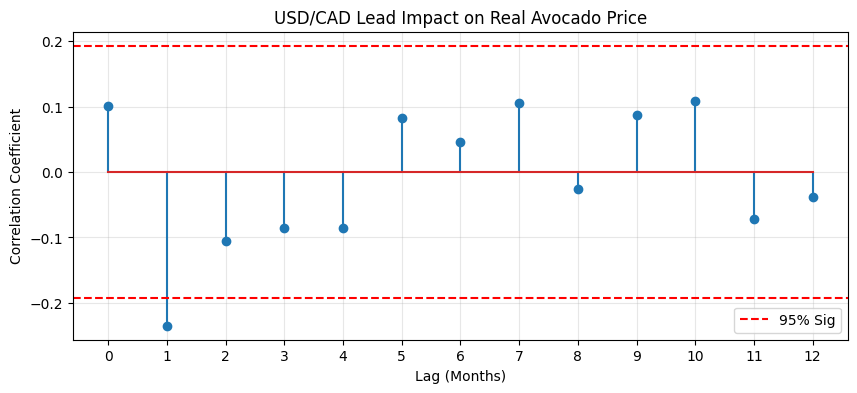

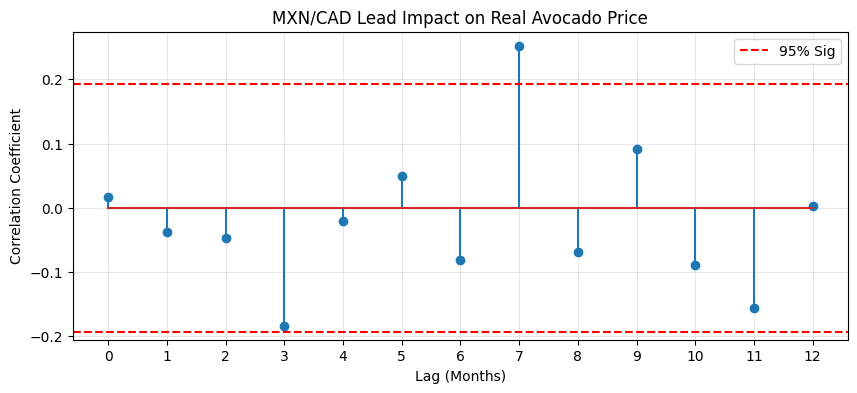

USD/CAD Lag 1 Correlation: -0.2351
MXN/CAD Lag 7 Correlation: 0.2524


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# 1. Preparation & Alignment
# Use the real_price (CPI adjusted) created earlier
df_fx_analysis = pd.merge(
    df_fx[['date', 'USD_CAD', 'MXN_CAD']],
    avocado_price_merged[['date', 'real_price']], # Use CPI-adjusted real_price
    on='date', how='inner'
).sort_values('date')

# 2. Differencing (Stationarity)
# difference to see how a JUMP in exchange rate leads to a JUMP in price
df_diff = np.log(df_fx_analysis[['real_price', 'USD_CAD', 'MXN_CAD']]).diff().dropna()

# 3. Calculate Significance Threshold
# N is approx 107; Threshold = 2/sqrt(N)
threshold = 2 / np.sqrt(len(df_diff))

# 4. CCF Calculation
usd_corr = ccf(df_diff['USD_CAD'], df_diff['real_price'])[:13]
mxn_corr = ccf(df_diff['MXN_CAD'], df_diff['real_price'])[:13]

# 5. Visualization Function (To keep code clean)
def plot_fx_ccf(correlations, title, color_line='r'):
    plt.figure(figsize=(10, 4))
    lags = np.arange(len(correlations))
    plt.stem(lags, correlations)
    plt.axhline(y=threshold, color=color_line, linestyle='--', label='95% Sig')
    plt.axhline(y=-threshold, color=color_line, linestyle='--')
    plt.title(title)
    plt.xlabel('Lag (Months)')
    plt.ylabel('Correlation Coefficient')
    plt.xticks(lags)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_fx_ccf(usd_corr, 'USD/CAD Lead Impact on Real Avocado Price')
plot_fx_ccf(mxn_corr, 'MXN/CAD Lead Impact on Real Avocado Price')

# 6. Print Specific Lag Values for your Report
print(f"USD/CAD Lag 1 Correlation: {usd_corr[1]:.4f}")
print(f"MXN/CAD Lag 7 Correlation: {mxn_corr[7]:.4f}")

3.1.3 weather

weather_index =
0.7 * Michoacán_weather +
0.2 * Jalisco_weather +
0.1 * Estado_de_Mexico_weather,

temperature: 0/1 month positive, 6 months negative

raining: 2 months positive, 7 months negative

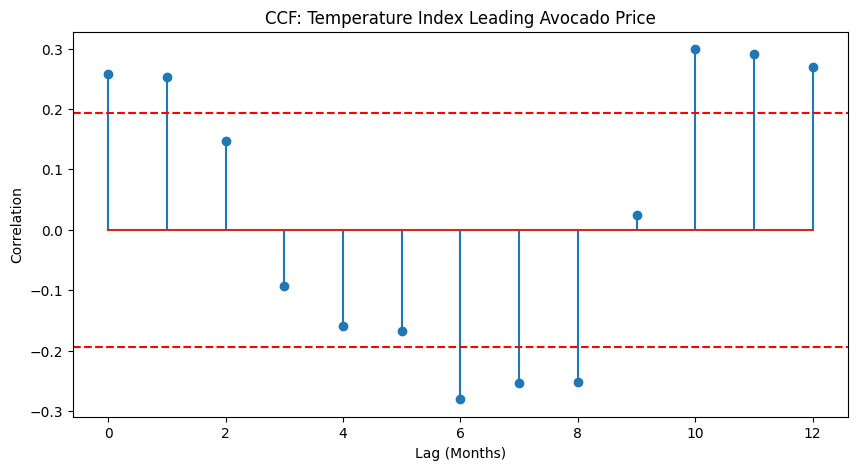

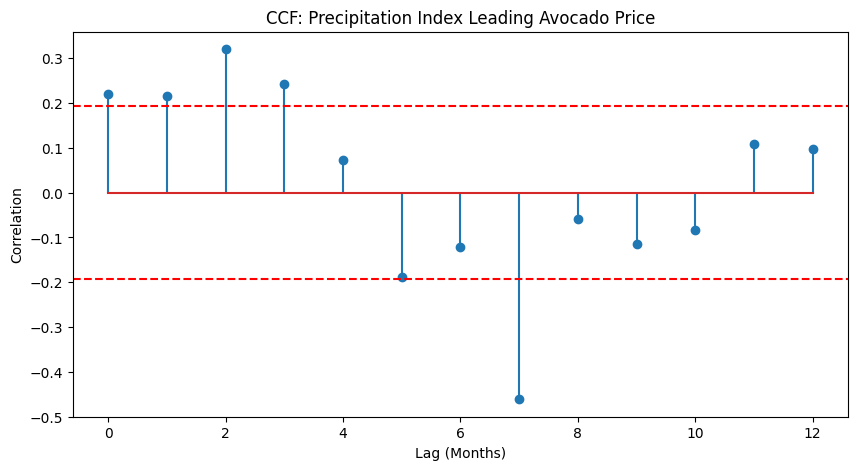

Temperature Lag Table: [ 0.25843897  0.2522413   0.14626921 -0.09371612 -0.15883011 -0.1680963
 -0.28047021 -0.25359692 -0.2527851   0.02414436  0.29885775  0.29138822
  0.26882087]
Precipitation Lag Table: [ 0.22035506  0.2151555   0.31998439  0.24324956  0.07235911 -0.18879823
 -0.12046058 -0.46107022 -0.05885824 -0.11480116 -0.08268988  0.1087111
  0.09800764]


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# 1. Load weather data
df_weather = pd.read_csv("mexico_weather_cleanedup.csv")
df_weather['date'] = pd.to_datetime(df_weather['PERIOD']).dt.strftime('%Y-%m')

# 2. Extract the three states
df_mich = df_weather[df_weather['STATE'] == 'Michoacán'][['date','MEAN_C','PRECIPITATION_MM']].copy()
df_jal = df_weather[df_weather['STATE'] == 'Jalisco'][['date','MEAN_C','PRECIPITATION_MM']].copy()
df_edomex = df_weather[df_weather['STATE'] == 'Estado de México'][['date','MEAN_C','PRECIPITATION_MM']].copy()

# Rename columns
df_mich = df_mich.rename(columns={'MEAN_C':'temp_mich','PRECIPITATION_MM':'prec_mich'})
df_jal = df_jal.rename(columns={'MEAN_C':'temp_jal','PRECIPITATION_MM':'prec_jal'})
df_edomex = df_edomex.rename(columns={'MEAN_C':'temp_edomex','PRECIPITATION_MM':'prec_edomex'})

# 3. Merge weather datasets
df_weather_index = df_mich.merge(df_jal, on='date', how='inner')
df_weather_index = df_weather_index.merge(df_edomex, on='date', how='inner')

# 4. Create weighted indices
df_weather_index['temp_weather_index'] = (
    0.7 * df_weather_index['temp_mich'] +
    0.2 * df_weather_index['temp_jal'] +
    0.1 * df_weather_index['temp_edomex']
)

df_weather_index['prec_weather_index'] = (
    0.7 * df_weather_index['prec_mich'] +
    0.2 * df_weather_index['prec_jal'] +
    0.1 * df_weather_index['prec_edomex']
)

# 5. Merge with avocado price
df = avocado_price_merged.merge(
    df_weather_index[['date','temp_weather_index','prec_weather_index']],
    on='date',
    how='left'
)

# 6. Create stationary series
y = np.log(df['real_price']).diff()

x_temp = df['temp_weather_index'].diff()
x_prec = df['prec_weather_index'].diff()

# 7. Combine and drop NaN to align
df_ccf = pd.concat([y, x_temp, x_prec], axis=1).dropna()
y = df_ccf['real_price']
x_temp = df_ccf['temp_weather_index']
x_prec = df_ccf['prec_weather_index']

# 8. Compute CCF
temp_lags = ccf(x_temp, y)[:13]
prec_lags = ccf(x_prec, y)[:13]

# 9. Significance threshold
N = len(df_ccf)
threshold = 2 / np.sqrt(N)

# 10. Plot temperature CCF
plt.figure(figsize=(10,5))
plt.stem(range(len(temp_lags)), temp_lags)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.axhline(y=-threshold, color='r', linestyle='--')
plt.title('CCF: Temperature Index Leading Avocado Price')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')
plt.show()

# 10. Plot precipitation CCF
plt.figure(figsize=(10,5))
plt.stem(range(len(prec_lags)), prec_lags)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.axhline(y=-threshold, color='r', linestyle='--')
plt.title('CCF: Precipitation Index Leading Avocado Price')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')
plt.show()

print("Temperature Lag Table:", temp_lags)
print("Precipitation Lag Table:", prec_lags)

In [ ]:
3.1.4 Canada imported data (2 months negative)

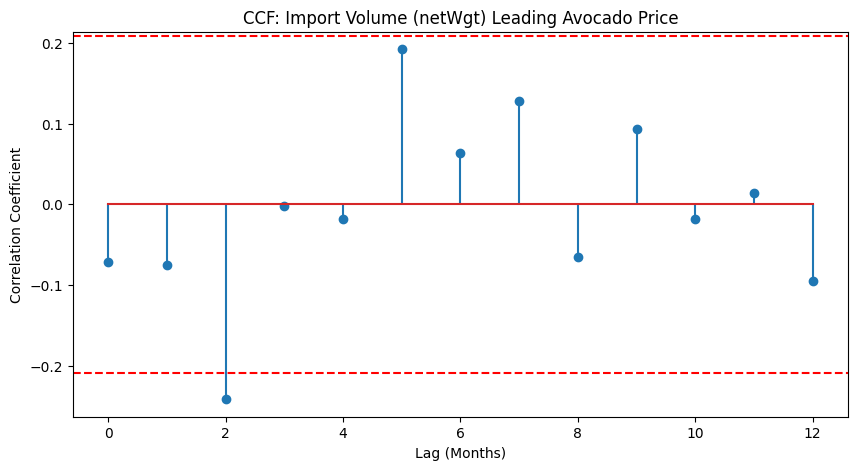

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# 1. Prepare Import Data (e.g., kilograms or dollars imported)
df_imports = pd.read_csv("avocado_imported_from_mexico.csv")
df_imports['date'] = pd.to_datetime(df_imports['refYear'].astype(str) + '-' +
                                    df_imports['refMonth'].astype(str)).dt.strftime('%Y-%m')

# 2. Merge into the Table：'netWgt' is usually the most reliable signal for actual volume
df_avocado_price_imports = avocado_price_merged.merge(df_imports[['date', 'netWgt']], on='date', how='left')
df_diff = df_avocado_price_imports[['real_price', 'netWgt']].diff().dropna()

# 3. Calculate CCF： ccf(x, y) where x is supply and y is price
import_corr = ccf(df_diff['netWgt'], df_diff['real_price'])[:13]
threshold = 2 / np.sqrt(len(df_diff))

# 4. Plot
plt.figure(figsize=(10, 5))
plt.stem(range(len(import_corr)), import_corr)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.axhline(y=-threshold, color='r', linestyle='--')
plt.title('CCF: Import Volume (netWgt) Leading Avocado Price')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation Coefficient')
plt.show()

3.1.5 Conclusion

1.   Fuel, 1 month, positive
*   1 month positive
*   4 months negative

2.   Exchange Rate
*   USD/CAD, 1 month, negative
*   MXN/CAD, 3 months, negative
*   MXN/CAD, 7 months, positive

3.   Weather
*   temperature:

    --- 0 month positive

    --- 6 months negative

*   raining:

    --- 2 months positive

    --- 7 months negative

4. Imported Data
*   2 months, negative




3.2 Tomato grocery price Lag: using CCF or corrcoef

3.2.1 fuel- 1 month positive, 4 months negative

Master dataframe created with 108 aligned months.
Shape of X: (107,)
Shape of Y: (107,)


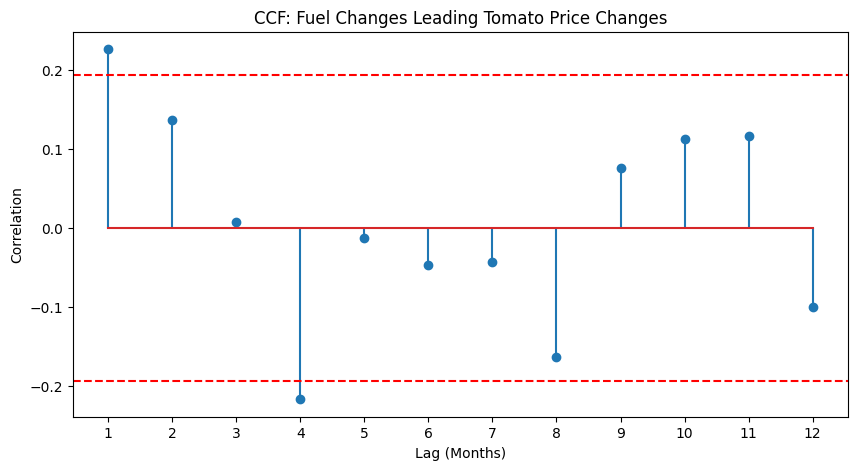

Strongest correlation at lag 1 months: 0.227


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Merge fuel and price data
df_ccf_price_fuel = pd.merge(
    fuel_signal[['date', 'total_fuel_signal']],
    tomato_price_merged[['date', 'real_price']],
    on='date',
    how='inner'
)
# Sort by time
df_ccf_price_fuel = df_ccf_price_fuel.sort_values('date').reset_index(drop=True)

print(f"Master dataframe created with {len(df_ccf_price_fuel)} aligned months.")

# 2. Log transform (economic data works better in logs)
df_log = np.log(df_ccf_price_fuel[['total_fuel_signal', 'real_price']])

# 3. Difference to remove trend
df_diff = df_log.diff().dropna()
x = df_diff['total_fuel_signal']   # Fuel
y = df_diff['real_price']          # tomato price

print(f"Shape of X: {x.shape}")
print(f"Shape of Y: {y.shape}")

# 4. Compute cross-correlation manually
# Fuel(t-lag) -> Price(t)
max_lag = 12
correlations = []

for lag in range(1, max_lag + 1):
    corr = np.corrcoef(x[:-lag], y[lag:])[0,1]
    correlations.append(corr)

lags = range(1, max_lag + 1)

# 5. Compute statistical confidence band
conf = 2 / np.sqrt(len(x))

# 6. Plot the CCF
plt.figure(figsize=(10,5))
plt.stem(lags, correlations)

plt.axhline(y=conf, color='red', linestyle='--')
plt.axhline(y=-conf, color='red', linestyle='--')

plt.title('CCF: Fuel Changes Leading Tomato Price Changes')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')

plt.xticks(lags)
plt.show()

# 7. Identify strongest lag
max_corr = max(correlations, key=abs)
best_lag = correlations.index(max_corr) + 1

print(f"Strongest correlation at lag {best_lag} months: {max_corr:.3f}")


3.2.2 Exchange rate (USD_CAD 1 month negative, MXN_CAD 3 months negative and 7 months positive)

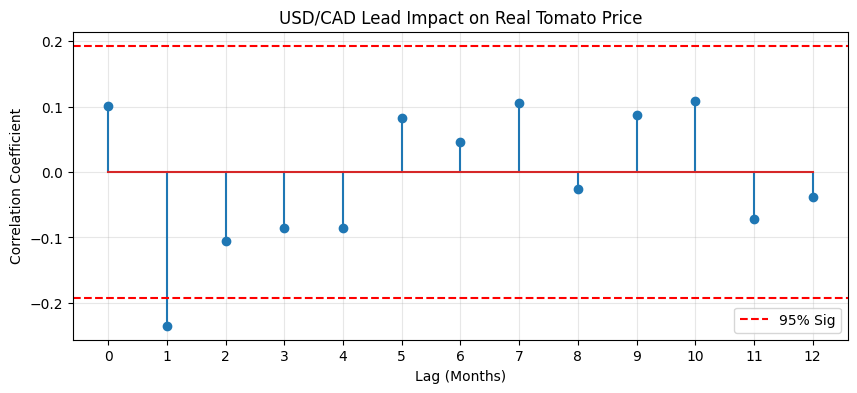

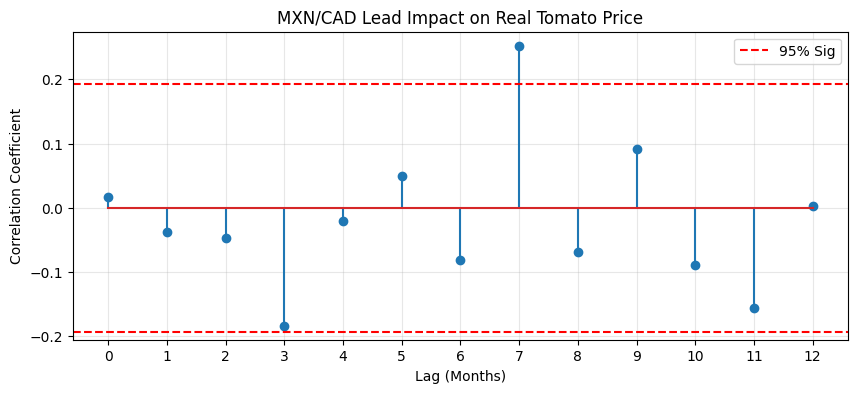

USD/CAD Lag 1 Correlation: -0.2351
MXN/CAD Lag 7 Correlation: 0.2524


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# 1. Preparation & Alignment
# Use the real_price (CPI adjusted) created earlier
df_fx_analysis = pd.merge(
    df_fx[['date', 'USD_CAD', 'MXN_CAD']],
    tomato_price_merged[['date', 'real_price']], # Use CPI-adjusted real_price
    on='date', how='inner'
).sort_values('date')

# 2. Differencing (Stationarity)
# difference to see how a JUMP in exchange rate leads to a JUMP in price
df_diff = np.log(df_fx_analysis[['real_price', 'USD_CAD', 'MXN_CAD']]).diff().dropna()

# 3. Calculate Significance Threshold
# N is approx 107; Threshold = 2/sqrt(N)
threshold = 2 / np.sqrt(len(df_diff))

# 4. CCF Calculation
usd_corr = ccf(df_diff['USD_CAD'], df_diff['real_price'])[:13]
mxn_corr = ccf(df_diff['MXN_CAD'], df_diff['real_price'])[:13]

# 5. Visualization Function (To keep code clean)
def plot_fx_ccf(correlations, title, color_line='r'):
    plt.figure(figsize=(10, 4))
    lags = np.arange(len(correlations))
    plt.stem(lags, correlations)
    plt.axhline(y=threshold, color=color_line, linestyle='--', label='95% Sig')
    plt.axhline(y=-threshold, color=color_line, linestyle='--')
    plt.title(title)
    plt.xlabel('Lag (Months)')
    plt.ylabel('Correlation Coefficient')
    plt.xticks(lags)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_fx_ccf(usd_corr, 'USD/CAD Lead Impact on Real Tomato Price')
plot_fx_ccf(mxn_corr, 'MXN/CAD Lead Impact on Real Tomato Price')

# 6. Print Specific Lag Values for your Report
print(f"USD/CAD Lag 1 Correlation: {usd_corr[1]:.4f}")
print(f"MXN/CAD Lag 7 Correlation: {mxn_corr[7]:.4f}")

3.2.3 weather

weather_index = Sinaloa_weather

temperature: 2 month positive, 8 months negative

raining: 3 months positive, 5 months negative

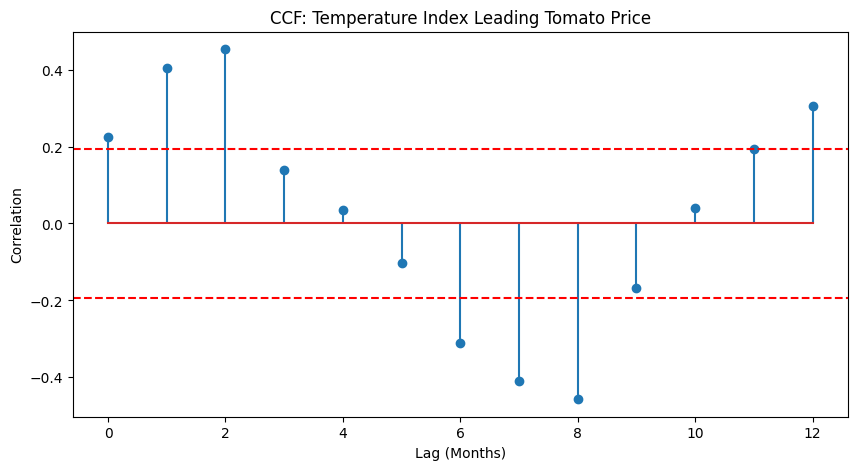

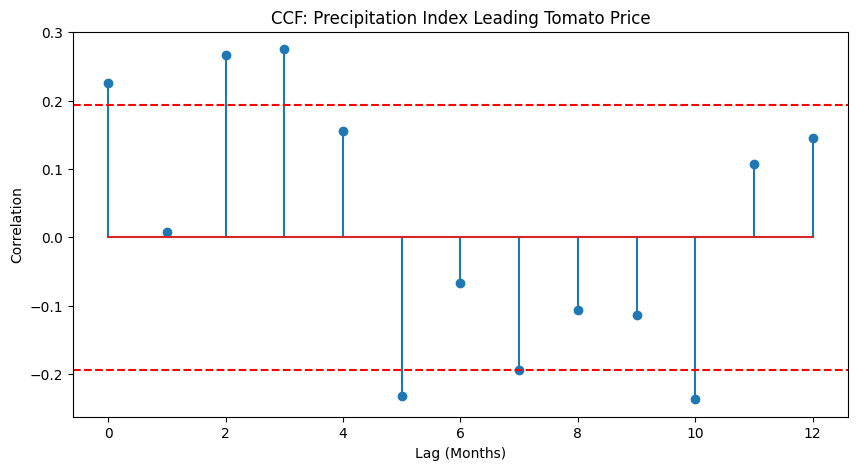

Temperature Lag Table: [ 0.2235959   0.403895    0.45291149  0.1401844   0.03438894 -0.10283316
 -0.31016673 -0.41045469 -0.45690689 -0.16853957  0.04018369  0.19442853
  0.30558254]
Precipitation Lag Table: [ 0.22520765  0.00818575  0.26640135  0.27497352  0.15530803 -0.23252513
 -0.06641171 -0.19426696 -0.10634836 -0.11361877 -0.23675815  0.10680774
  0.145389  ]


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# 1. Load weather data
df_weather = pd.read_csv("mexico_weather_cleanedup.csv")
df_weather['date'] = pd.to_datetime(df_weather['PERIOD']).dt.strftime('%Y-%m')

# 2. Extract the three states
df_sina = df_weather[df_weather['STATE'] == 'Sinaloa'][['date','MEAN_C','PRECIPITATION_MM']].copy()

# 3. Rename columns
df_sina = df_sina.rename(columns={'MEAN_C':'temp_sina','PRECIPITATION_MM':'prec_sina'})

# 4. Create weighted indices
df_weather_index = df_sina.copy()
df_weather_index['temp_weather_index'] = df_weather_index['temp_sina']
df_weather_index['prec_weather_index'] = df_weather_index['prec_sina']

# 5. Merge with avocado price
df = tomato_price_merged.merge(
    df_weather_index[['date','temp_weather_index','prec_weather_index']],
    on='date',
    how='left'
)

# 6. Create stationary series
y = np.log(df['real_price']).diff()

x_temp = df['temp_weather_index'].diff()
x_prec = df['prec_weather_index'].diff()

# 7. Combine and drop NaN to align
df_ccf = pd.concat([y, x_temp, x_prec], axis=1).dropna()
y = df_ccf['real_price']
x_temp = df_ccf['temp_weather_index']
x_prec = df_ccf['prec_weather_index']

# 8. Compute CCF
temp_lags = ccf(x_temp, y)[:13]
prec_lags = ccf(x_prec, y)[:13]

# 9. Significance threshold
N = len(df_ccf)
threshold = 2 / np.sqrt(N)

# 10. Plot temperature CCF
plt.figure(figsize=(10,5))
plt.stem(range(len(temp_lags)), temp_lags)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.axhline(y=-threshold, color='r', linestyle='--')
plt.title('CCF: Temperature Index Leading Tomato Price')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')
plt.show()

# 11. Plot precipitation CCF
plt.figure(figsize=(10,5))
plt.stem(range(len(prec_lags)), prec_lags)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.axhline(y=-threshold, color='r', linestyle='--')
plt.title('CCF: Precipitation Index Leading Tomato Price')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')
plt.show()

print("Temperature Lag Table:", temp_lags)
print("Precipitation Lag Table:", prec_lags)

In [ ]:
3.1.4 Canada imported data (0 month negative, 7 months positive)

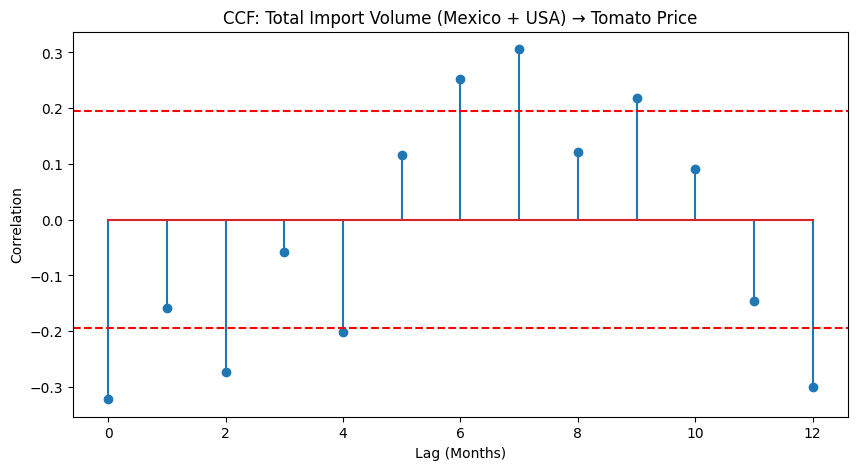

[-0.32209306 -0.1581215  -0.27289804 -0.0584412  -0.20172386  0.11596415
  0.25175066  0.30575284  0.12162453  0.21741372  0.09029007 -0.14530908
 -0.29996773]


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# 1. Load import data
df_imports = pd.read_csv("tomato_import_mexico_us.csv")

# Create monthly date
df_imports['date'] = pd.to_datetime(
    df_imports['refYear'].astype(str) + '-' +
    df_imports['refMonth'].astype(str)
).dt.strftime('%Y-%m')

# 2. Aggregate imports by month (Mexico + USA)
df_monthly_imports = (
    df_imports.groupby('date')['netWgt']
    .sum()
    .reset_index()
)

# 3. Merge with tomato price data
df_tomato_price_imports = tomato_price_merged.merge(
    df_monthly_imports,
    on='date',
    how='inner'
)

# 4. Stationary series
df_diff = pd.DataFrame({
    'price_diff': np.log(df_tomato_price_imports['real_price']).diff(),
    'import_diff': df_tomato_price_imports['netWgt'].diff()
}).dropna()

# 5. Compute CCF
import_corr = ccf(df_diff['import_diff'], df_diff['price_diff'])[:13]

# Significance threshold
threshold = 2 / np.sqrt(len(df_diff))

# 6. Plot
plt.figure(figsize=(10,5))
plt.stem(range(len(import_corr)), import_corr)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.axhline(y=-threshold, color='r', linestyle='--')
plt.title('CCF: Total Import Volume (Mexico + USA) → Tomato Price')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation')
plt.show()

print(import_corr)

3.2.5 Conclusion

1.   Fuel, 1 month, positive
*   1 month positive
*   4 months negative

2.   Exchange Rate
*   USD/CAD, 1 month, negative
*   MXN/CAD, 3 months, negative
*   MXN/CAD, 7 months, positive

3.   Weather
*   temperature:

    --- 2 month positive

    --- 8 months negative

*   raining:

    --- 3 months positive

    --- 5 months negative

4. Imported Data
*   0 months, negative
*   7 month positive


